[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/oalnaseri/mobilcom_course/blob/main/08_tapped_delay_line_interactive.ipynb)

> **Run this notebook in Google Colab** — click the badge above (no local install needed).
> The setup cell below installs dependencies and enables interactive `ipywidgets` sliders in Colab.

---

# 🎛️ Tapped Delay Line (TDL) Channel Model
### Interactive Teaching Notebook — DHBW Mobile Communications
---
The lecture slide shows the TDL as a chain of delay blocks **T** with time-variant weights
$h_i(t)$ — an **FIR filter**. This notebook builds that filter, gives its taps the right
statistics (**Rayleigh** for NLOS, **Rice** for LOS) and lets you watch what it does to a
real signal.

Why bother? Because a stochastic model needs **no 3D model of the city** and runs in
milliseconds, while ray tracing needs a full building database and runs for hours.

---

In [1]:
# ============================================================
#  COLAB / ENVIRONMENT SETUP  (safe to run locally too)
# ============================================================
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # numpy + matplotlib ship with Colab; ensure ipywidgets is present
    !pip install -q ipywidgets

    # Required so ipywidgets sliders / interactive output render in Colab
    from google.colab import output
    output.enable_custom_widget_manager()

print("Environment ready.  IN_COLAB =", IN_COLAB)

Environment ready.  IN_COLAB = False


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#f5f5f5'
c0 = 3e8
print("Libraries loaded.")

Libraries loaded.


## 📚 Theory Reference

### The model
$$y(t)=\sum_{i=1}^{L} h_i(t)\; x\!\left(t-\tau_i\right)$$

* $\tau_i$ — the delay of tap $i$ (the **T** blocks on the slide)
* $h_i(t)$ — a **complex, time-variant, stochastic** coefficient (the $\times$ blocks)

### Tap statistics
Each tap is the sum of many unresolvable sub-paths. By the central limit theorem the
in-phase and quadrature parts become Gaussian, so the **magnitude** follows

| Scenario | Magnitude distribution | $K$ |
|---|---|---|
| **NLOS** — no direct path | **Rayleigh** $\ p(r)=\frac{r}{\sigma^2}e^{-r^2/2\sigma^2}$ | $K=0$ |
| **LOS** — one dominant path | **Rice** $\ p(r)=\frac{r}{\sigma^2}e^{-(r^2+A^2)/2\sigma^2}I_0\!\left(\frac{rA}{\sigma^2}\right)$ | $K=\frac{A^2}{2\sigma^2}$ |

The **Rice factor** $K$ is the power ratio of the dominant path to all the scattered ones.
$K\to 0$ gives Rayleigh back; $K\to\infty$ gives a constant (no fading at all).

### Time variance
The taps are made time-variant by the Doppler process of the previous notebook:
each sub-path gets its own $f_{D}=f_{D,max}\cos\varphi$, so
$$h_i(t)=\sum_k a_{ik}\,e^{\,j(2\pi f_{D,ik}t+\theta_{ik})}$$

### What you get out
* the **channel impulse response** $|h_i|$ over delay — the PDP again, but now one realisation
* the **transfer function** $H(f,t)$ — frequency-selective notches that move with time
* the **output signal** — pulses smeared into each other: **inter-symbol interference**

---

In [3]:
# ---------------------------------------------------------------
#  CORE: build a Tapped Delay Line channel
# ---------------------------------------------------------------
# COST 207 "Typical Urban" (6-tap) profile -- a classic textbook PDP
COST207_TU6 = dict(tau_us=np.array([0.0, 0.2, 0.5, 1.6, 2.3, 5.0]),
                   P_dB  =np.array([-3.0, 0.0, -2.0, -6.0, -8.0, -10.0]))

# COST 207 "Bad Urban" (6-tap) -- long echoes, much larger delay spread
COST207_BU6 = dict(tau_us=np.array([0.0, 0.4, 1.0, 1.6, 5.0, 6.6]),
                   P_dB  =np.array([-3.0, 0.0, -3.0, -5.0, -2.0, -4.0]))

def tdl_taps(tau_us, P_dB, fdmax, t, K_dB=None, n_sub=30, seed=0):
    """Time-variant tap coefficients h_i(t).
    K_dB = None -> all taps Rayleigh (NLOS)
    K_dB = value -> first tap Rice with that K factor (LOS), rest Rayleigh."""
    rng  = np.random.default_rng(seed)
    P    = 10.0**(np.asarray(P_dB, float)/10.0)
    L    = P.size
    H    = np.zeros((L, t.size), dtype=complex)
    for i in range(L):
        phi = rng.uniform(0, 2*np.pi, n_sub)          # isotropic sub-paths
        fd  = fdmax*np.cos(phi)
        th  = rng.uniform(0, 2*np.pi, n_sub)
        a   = rng.rayleigh(1.0, n_sub)
        diff = (a*np.exp(1j*th)) @ np.exp(2j*np.pi*np.outer(fd, t))
        diff /= np.sqrt((np.abs(diff)**2).mean())     # unit mean power
        if K_dB is not None and i == 0:
            K   = 10.0**(K_dB/10.0)
            los = np.exp(2j*np.pi*fdmax*np.cos(np.deg2rad(20))*t)   # one steady path
            h   = (np.sqrt(K/(K+1))*los + np.sqrt(1/(K+1))*diff)
        else:
            h = diff
        H[i] = np.sqrt(P[i]) * h
    return H                                          # shape (L, len(t))

def tdl_transfer(tau_us, H, f_MHz):
    """H(f,t) from the taps."""
    tau = np.asarray(tau_us, float)*1e-6
    f   = np.asarray(f_MHz, float)*1e6
    E   = np.exp(-2j*np.pi*np.outer(f, tau))          # (F, L)
    return E @ H                                      # (F, T)

def tdl_filter(tau_us, H_col, x, fs_Hz):
    """Apply one snapshot of the channel to a signal x sampled at fs."""
    delays = np.round(np.asarray(tau_us, float)*1e-6*fs_Hz).astype(int)
    y = np.zeros(x.size + delays.max(), dtype=complex)
    for d, h in zip(delays, H_col):
        y[d:d+x.size] += h*x
    return y[:x.size]

def rayleigh_pdf(r, sigma=1.0):
    return r/sigma**2*np.exp(-r**2/(2*sigma**2))

def _i0e(z):
    """Exponentially scaled modified Bessel function I0(z)*exp(-z).
    Series for small z, asymptotic expansion for large z -> no overflow."""
    z   = np.asarray(z, float)
    out = np.empty_like(z)
    small = z < 15.0
    # --- series: term_k = term_{k-1} * (z/2)^2 / k^2 ------------------
    zs   = z[small]
    term = np.ones_like(zs); tot = np.ones_like(zs)
    for k in range(1, 60):
        term = term*(zs/2.0)**2/k**2
        tot += term
    out[small] = tot*np.exp(-zs)
    # --- asymptotic: I0(z) ~ e^z/sqrt(2 pi z) * (1 + 1/(8z) + 9/(128 z^2)) ---
    zl = z[~small]
    out[~small] = (1.0/np.sqrt(2*np.pi*zl))*(1 + 1/(8*zl) + 9/(128*zl**2))
    return out

def rice_pdf(r, K, Omega=1.0):
    """Rice pdf with Rice factor K and mean power Omega."""
    A  = np.sqrt(K*Omega/(K+1)); s2 = Omega/(2*(K+1))
    z  = r*A/s2
    return r/s2*np.exp(-(r**2 + A**2)/(2*s2) + z)*_i0e(z)

print("TDL model ready.")

TDL model ready.


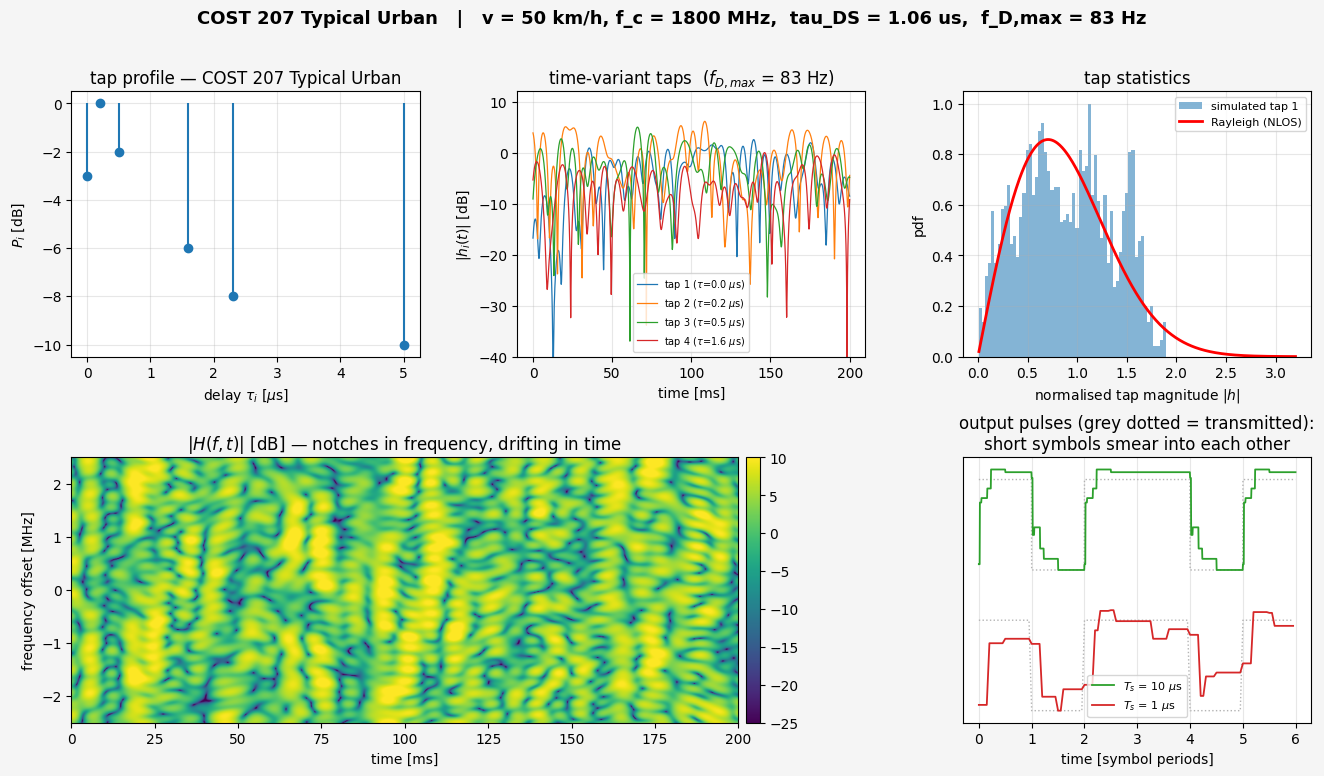

delay spread = 1.06 us  ->  coherence bandwidth ~ 1/(5*tau_DS) = 188 kHz


In [4]:
# ---------------------------------------------------------------
#  ONE COMPLETE PICTURE OF A TDL CHANNEL
# ---------------------------------------------------------------
def plot_tdl(profile=COST207_TU6, v_kmh=50, fc_MHz=1800, K_dB=None,
             T_ms=200.0, seed=3, name="COST 207 Typical Urban"):
    tau, PdB = profile['tau_us'], profile['P_dB']
    fdmax = (v_kmh/3.6)*(fc_MHz*1e6)/c0
    t  = np.linspace(0, T_ms*1e-3, 3000)
    H  = tdl_taps(tau, PdB, fdmax, t, K_dB=K_dB, seed=seed)

    fsw = np.linspace(-2.5, 2.5, 400)                       # MHz around the carrier
    Hf  = tdl_transfer(tau, H, fsw)

    fig = plt.figure(figsize=(16, 8.2))
    gs  = fig.add_gridspec(2, 3, hspace=.38, wspace=.28)

    # 1) the profile / impulse response
    ax = fig.add_subplot(gs[0, 0])
    ax.stem(tau, PdB, basefmt=" ", linefmt="C0-", markerfmt="C0o")
    ax.set_xlabel(r"delay $\tau_i$ [$\mu$s]"); ax.set_ylabel(r"$P_i$ [dB]")
    ax.set_title(f"tap profile — {name}"); ax.grid(alpha=.3)

    # 2) taps over time
    ax = fig.add_subplot(gs[0, 1])
    for i in range(min(4, H.shape[0])):
        ax.plot(t*1000, 20*np.log10(np.abs(H[i])), lw=.9,
                label=fr"tap {i+1} ($\tau$={tau[i]} $\mu$s)")
    ax.set_xlabel("time [ms]"); ax.set_ylabel(r"$|h_i(t)|$ [dB]")
    ax.set_ylim(-40, 12); ax.legend(fontsize=7); ax.grid(alpha=.3)
    ax.set_title(f"time-variant taps  ($f_{{D,max}}$ = {fdmax:.0f} Hz)")

    # 3) amplitude histogram vs theory
    ax = fig.add_subplot(gs[0, 2])
    r  = np.abs(H[0]) / np.sqrt((np.abs(H[0])**2).mean())
    ax.hist(r, bins=60, density=True, alpha=.55, color="C0", label="simulated tap 1")
    rr = np.linspace(0.01, 3.2, 400)
    ax.plot(rr, rayleigh_pdf(rr, 1/np.sqrt(2)), 'r-', lw=2, label="Rayleigh (NLOS)")
    if K_dB is not None:
        ax.plot(rr, rice_pdf(rr, 10**(K_dB/10)), 'b-', lw=2,
                label=f"Rice, K = {K_dB:.0f} dB (LOS)")
    ax.set_xlabel(r"normalised tap magnitude $|h|$"); ax.set_ylabel("pdf")
    ax.legend(fontsize=8); ax.grid(alpha=.3); ax.set_title("tap statistics")

    # 4) |H(f,t)| as an image  -> frequency-selective fading moving in time
    ax = fig.add_subplot(gs[1, :2])
    im = ax.imshow(20*np.log10(np.abs(Hf)), aspect='auto', origin='lower',
                   extent=[0, T_ms, fsw[0], fsw[-1]], cmap='viridis',
                   vmin=-25, vmax=10)
    ax.set_xlabel("time [ms]"); ax.set_ylabel("frequency offset [MHz]")
    ax.set_title(r"$|H(f,t)|$ [dB] — notches in frequency, drifting in time")
    fig.colorbar(im, ax=ax, pad=.01)

    # 5) inter-symbol interference on a pulse train
    ax = fig.add_subplot(gs[1, 2])
    bits = [1, 0, 1, 1, 0, 1]
    for Ts_us, col, off in [(10.0, 'C2', 1.4), (1.0, 'C3', 0.0)]:
        fs  = 20e6
        sps = int(Ts_us*1e-6*fs); n = 6*sps
        x   = np.zeros(n)
        for k, b_ in enumerate(bits):
            x[k*sps:(k+1)*sps] = b_
        y  = tdl_filter(tau, H[:, 0], x, fs)
        tt = np.arange(n)/sps                      # in SYMBOL periods
        ax.plot(tt, np.abs(x)*0.9+off, color='0.7', lw=1.0, ls=':')
        ax.plot(tt, np.abs(y)/np.abs(y).max()+off, color=col, lw=1.3,
                label=fr"$T_s$ = {Ts_us:.0f} $\mu$s")
    ax.set_xlabel("time [symbol periods]"); ax.set_yticks([])
    ax.set_title("output pulses (grey dotted = transmitted):\n"
                 "short symbols smear into each other")
    ax.legend(fontsize=8); ax.grid(alpha=.3)

    P = 10**(PdB/10); tb = (P*tau).sum()/P.sum()
    tds = np.sqrt((P*tau**2).sum()/P.sum() - tb**2)
    fig.suptitle(f"{name}   |   v = {v_kmh} km/h, f_c = {fc_MHz} MHz,  "
                 f"tau_DS = {tds:.2f} us,  f_D,max = {fdmax:.0f} Hz",
                 fontsize=13, fontweight="bold")
    plt.show()
    return tds, fdmax

tds, fdm = plot_tdl()
print(f"delay spread = {tds:.2f} us  ->  coherence bandwidth ~ 1/(5*tau_DS) "
      f"= {1/(5*tds*1e-6)/1e3:.0f} kHz")

In [5]:
# ---------------------------------------------------------------
#  INTERACTIVE
# ---------------------------------------------------------------
PROFILES = {'COST 207 Typical Urban': COST207_TU6,
            'COST 207 Bad Urban':     COST207_BU6}

style  = {'description_width': '200px'}
layout = widgets.Layout(width='540px')

dd_prof = widgets.Dropdown(options=list(PROFILES), value='COST 207 Typical Urban',
             description='delay profile:', style=style, layout=layout)
sl_v    = widgets.FloatSlider(value=50, min=1, max=350, step=1,
             description='speed v [km/h]:', style=style, layout=layout)
sl_fc   = widgets.FloatSlider(value=1800, min=400, max=6000, step=100,
             description='carrier f_c [MHz]:', style=style, layout=layout)
tg_los  = widgets.ToggleButtons(options=[('NLOS (Rayleigh)', None), ('LOS (Rice)', 6.0)],
             value=None, description='scenario:', style=style)
sl_K    = widgets.FloatSlider(value=6, min=-6, max=20, step=1,
             description='Rice factor K [dB]:', style=style, layout=layout)
sl_seed = widgets.IntSlider(value=3, min=0, max=40, step=1,
             description='realisation (seed):', style=style, layout=layout)

def update(prof, v, fc, los, K, seed):
    K_dB = K if los is not None else None
    plot_tdl(PROFILES[prof], v, fc, K_dB=K_dB, seed=seed, name=prof)

ui  = widgets.VBox([dd_prof, sl_v, sl_fc, tg_los, sl_K, sl_seed])
out = widgets.interactive_output(update, {'prof': dd_prof, 'v': sl_v, 'fc': sl_fc,
                                          'los': tg_los, 'K': sl_K, 'seed': sl_seed})
display(ui, out)

Output()

## 📝 Try this

1. **Rayleigh vs. Rice.** Switch to LOS and raise $K$ from $-6$ dB to $20$ dB. Watch the
   histogram move away from zero and the tap trace in the top-middle panel stop diving into
   deep fades. That is the whole difference between standing in the open and standing
   behind a building.
2. **Typical Urban vs. Bad Urban.** Bad Urban has echoes out to 6.6 µs. Look at the
   $|H(f,t)|$ image: the notches get much closer together in frequency, because
   $B_{Korr}\sim 1/\tau_{DS}$. Same physics as notebook 06, now visible as a picture.
3. **Speed.** Raise $v$ from 1 to 350 km/h. The notches in the image start drifting
   sideways faster and faster — that is the coherence time shrinking (notebook 07).
   At walking pace the channel is essentially frozen.
4. **The ISI panel.** With $T_s = 10\,\mu$s the pulses stay separate; with
   $T_s = 1\,\mu$s they smear into each other, because $\tau_{DS}$ is now comparable to
   the symbol. This is *why* high data rates need an equaliser or OFDM — not an opinion,
   a picture.

## 📌 Summary

The TDL model is the workhorse of link-level simulation:

| Needs | Gives |
|---|---|
| a delay profile $(\tau_i, P_i)$ | a full time-variant channel |
| a Doppler frequency $f_{D,max}$ | realistic fading statistics |
| a scenario flag (LOS / NLOS) | Rice or Rayleigh taps |

No building database, no Maxwell solver, milliseconds of compute — and statistically it
behaves like the real thing. That is exactly the trade-off the "classification of channel
models" slide is about.